# Benchmark, Inference, FanchuanUnlearning, SCRUB, and DELETE

Load baseline checkpoints, preview predictions, run FanchuanUnlearning, SCRUB, and DELETE, and benchmark all model families.

In [8]:
from pathlib import Path

import json
import matplotlib.pyplot as plt

from data_utils import resolve_pipeline_paths

from notebook_workflows import (
    preview_checkpoint_predictions,
    results_to_dataframe,
    run_benchmark_notebook_workflow,
    run_fanchuan_unlearning_workflow,
    run_scrub_unlearning_workflow,
    run_delete_unlearning_workflow,
)


In [ ]:
# Centralized config
DATASET = "cifar10"
DEVICE = "auto"
NUM_BANK_SEEDS = 3
CHECKPOINT_DIR = Path("checkpoints")
BASELINE_TRAIN_FAMILY = "baseline_train"
BASELINE_RETRAIN_FAMILY = "baseline_retrain"
UNLEARNING_METHODS = {
    "FanchuanUnlearning": {
        "runner": run_fanchuan_unlearning_workflow,
        "profile": DATASET,
    },
    "SCRUB": {
        "runner": run_scrub_unlearning_workflow,
        "profile": DATASET,
    },
    "DELETE": {
        "runner": run_delete_unlearning_workflow,
        "profile": DATASET,
    },
}
PREVIEW_FAMILY = "FanchuanUnlearning"
UNLEARN_REUSE_EXISTING = True
UNLEARN_EFFICIENCY_AWARE = True
EVAL_BATCH_SIZE = 128 if DATASET == "cifar10" else 64
IMAGE_SIZE = 32 if DATASET == "cifar10" else 224
EFFICIENCY_RATIO = 0.20
UNLEARN_USE_WANDB = True
UNLEARN_WANDB_PROJECT = None
BENCHMARK_USE_WANDB = True
BENCHMARK_WANDB_PROJECT = "benchmark"

DATA_ROOT = None
TASK_MANIFEST = None
SAMPLES_CSV = None


In [10]:
_, resolved_task_manifest, _ = resolve_pipeline_paths(DATASET, SAMPLES_CSV, TASK_MANIFEST, DATA_ROOT)
TASK_ID = json.loads(resolved_task_manifest.read_text(encoding="utf-8"))["task_id"]
baseline_train_dir = CHECKPOINT_DIR / DATASET / TASK_ID / BASELINE_TRAIN_FAMILY
baseline_retrain_dir = CHECKPOINT_DIR / DATASET / TASK_ID / BASELINE_RETRAIN_FAMILY
unlearn_outputs_by_family = {}
for family_name, method_config in UNLEARNING_METHODS.items():
    unlearn_outputs_by_family[family_name] = method_config["runner"](
        dataset=DATASET,
        base_family_dir=baseline_train_dir,
        output_family_name=family_name,
        num_bank_seeds=NUM_BANK_SEEDS,
        profile=method_config["profile"],
        checkpoint_dir=CHECKPOINT_DIR,
        data_root=DATA_ROOT,
        task_manifest=TASK_MANIFEST,
        samples_csv=SAMPLES_CSV,
        device_name=DEVICE,
        use_wandb=UNLEARN_USE_WANDB,
        wandb_project=UNLEARN_WANDB_PROJECT,
        image_size=IMAGE_SIZE,
        reuse_existing=UNLEARN_REUSE_EXISTING,
        efficiency_aware=UNLEARN_EFFICIENCY_AWARE,
        reference_family_dir=baseline_retrain_dir,
        efficiency_ratio=EFFICIENCY_RATIO,
    )

unlearn_outputs_by_family


FanchuanUnlearning efficiency search (FanchuanUnlearning):   0%|          | 0/4 [00:00<?, ?it/s]

SCRUB efficiency search (SCRUB):   0%|          | 0/6 [00:00<?, ?it/s]

SCRUB seed bank (SCRUB):   0%|          | 0/3 [00:00<?, ?it/s]

SCRUB epochs (SCRUB, seed 0):   0%|          | 0/3 [00:00<?, ?it/s]

SCRUB forget:   0%|          | 0/71 [00:00<?, ?it/s]

...

SCRUB retain:   0%|          | 0/1266 [00:00<?, ?it/s]

SCRUB forget:   0%|          | 0/71 [00:00<?, ?it/s]

SCRUB retain:   0%|          | 0/1266 [00:00<?, ?it/s]

SCRUB retain:   0%|          | 0/1266 [00:00<?, ?it/s]

{'FanchuanUnlearning': {'family_name': 'FanchuanUnlearning',
  'seed_bank': [{'dataset': 'cifar10',
    'task_id': 'forget_mixed',
    'run_name': 'FanchuanUnlearning',
    'train_split': 'retain',
    'seed': 0,
    'epochs': 6,
    'batch_size': 64,
    'learning_rate': 0.0003,
    'momentum': 0.9,
    'weight_decay': 0.0,
    'class_weighting': 'none',
    'num_classes': 10,
    'label_to_index': {'0': 0,
     '1': 1,
     '2': 2,
     '3': 3,
     '4': 4,
     '5': 5,
     '6': 6,
     '7': 7,
     '8': 8,
     '9': 9},
    'class_names': ['airplane',
     'automobile',
     'bird',
     'cat',
     'deer',
     'dog',
     'frog',
     'horse',
     'ship',
     'truck'],
    'runtime_seconds': 104.19957479999721,
    'wall_clock_seconds': 108.92308650000086,
    'runtime_excludes_validation': True,
    'best_val_accuracy': 0.8406,
    'final_val_accuracy': 0.8406,
    'checkpoint_path': 'checkpoints\\cifar10\\forget_mixed\\FanchuanUnlearning\\seed_0.pth',
    'epochs_logged': [{'

In [11]:
preview_family_name = PREVIEW_FAMILY if PREVIEW_FAMILY in unlearn_outputs_by_family else next(iter(unlearn_outputs_by_family))
preview_outputs = unlearn_outputs_by_family[preview_family_name]
prediction_preview = preview_checkpoint_predictions(
    dataset=DATASET,
    checkpoint_path=preview_outputs["seed_bank"][0]["checkpoint_path"],
    loader_name="test",
    sample_count=5,
    batch_size=EVAL_BATCH_SIZE,
    image_size=IMAGE_SIZE,
    data_root=DATA_ROOT,
    task_manifest=TASK_MANIFEST,
    samples_csv=SAMPLES_CSV,
    device_name=DEVICE,
)

display(results_to_dataframe(prediction_preview))


,loader,target_index,target_label,predicted_index,predicted_label,predicted_probability,probabilities
0,test,3,cat,3,cat,0.990648,"[0.00021601418848149478, 0.0004316922859288752..."
1,test,8,ship,8,ship,0.999909,"[7.89498517406173e-06, 7.93993822298944e-05, 1..."
2,test,8,ship,8,ship,0.960318,"[0.0067659905180335045, 0.02613948844373226, 0..."
3,test,0,airplane,0,airplane,0.926360,"[0.9263596534729004, 0.0030456162057816982, 0...."
4,test,6,frog,6,frog,0.890465,"[0.0007367937942035496, 0.004933335352689028, ..."


In [12]:
benchmark_outputs = run_benchmark_notebook_workflow(
    dataset=DATASET,
    checkpoint_dir=CHECKPOINT_DIR,
    baseline_train_family=BASELINE_TRAIN_FAMILY,
    baseline_retrain_family=BASELINE_RETRAIN_FAMILY,
    candidate_family_dirs={
        family_name: outputs["family_dir"]
        for family_name, outputs in unlearn_outputs_by_family.items()
    },
    efficiency_ratio=EFFICIENCY_RATIO,
    data_root=DATA_ROOT,
    task_manifest=TASK_MANIFEST,
    samples_csv=SAMPLES_CSV,
    device_name=DEVICE,
    batch_size=EVAL_BATCH_SIZE,
    image_size=IMAGE_SIZE,
    use_wandb=BENCHMARK_USE_WANDB,
    wandb_project=BENCHMARK_WANDB_PROJECT,
)

benchmark_outputs


Benchmarking Families:   0%|          | 0/4 [00:00<?, ?it/s]

Evaluating Checkpoints:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating Checkpoints:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating Checkpoints:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating Checkpoints:   0%|          | 0/3 [00:00<?, ?it/s]

...

Scoring Forget Examples (baseline_train):   0%|          | 0/4500 [00:00<?, ?it/s]

Scoring Forget Examples (FanchuanUnlearning):   0%|          | 0/4500 [00:00<?, ?it/s]

Scoring Forget Examples (SCRUB):   0%|          | 0/4500 [00:00<?, ?it/s]

comparison/FanchuanUnlearning/candidate_retain_accuracy,▁
comparison/FanchuanUnlearning/candidate_runtime_mean,▁
comparison/FanchuanUnlearning/candidate_test_accuracy,▁
comparison/FanchuanUnlearning/final_score,▁
comparison/FanchuanUnlearning/forgetting_quality,▁
comparison/FanchuanUnlearning/raw_final_score,▁
comparison/FanchuanUnlearning/reference_retain_accuracy,▁
comparison/FanchuanUnlearning/reference_runtime_mean,▁
comparison/FanchuanUnlearning/reference_test_accuracy,▁
comparison/SCRUB/candidate_retain_accuracy,▁
+32,...


{'dataset': 'cifar10',
 'reference_family': 'baseline_retrain',
 'family_summaries': {'baseline_train': {'retain_accuracy_mean': 1.0,
   'test_accuracy_mean': 0.8403,
   'runtime_seconds_mean': 607.5263268333341,
   'num_models': 3},
  'baseline_retrain': {'retain_accuracy_mean': 1.0,
   'test_accuracy_mean': 0.8262,
   'runtime_seconds_mean': 549.7587966000004,
   'num_models': 3},
  'FanchuanUnlearning': {'retain_accuracy_mean': 0.9998765432098765,
   'test_accuracy_mean': 0.8360333333333333,
   'runtime_seconds_mean': 104.4445404666664,
   'num_models': 3},
  'SCRUB': {'retain_accuracy_mean': 0.48937448559670776,
   'test_accuracy_mean': 0.46973333333333334,
   'runtime_seconds_mean': 79.26616273333396,
   'num_models': 3}},
 'comparisons_to_reference': {'baseline_train': {'forgetting_quality': 0.20844444444444443,
   'per_example_epsilons': [50.0,
    50.0,
    50.0,
    50.0,
    0.6931321804474443,
    50.0,
    50.0,
    0.6931321804474443,
    50.0,
    50.0,
    50.0,
    50.0

In [13]:
family_df = results_to_dataframe(
    [
        {"family": family_name, **summary}
        for family_name, summary in benchmark_outputs["family_summaries"].items()
    ]
)
display(family_df)

comparison_df = results_to_dataframe(
    [
        {
            "family": family_name,
            "forgetting_quality": comparison["forgetting_quality"],
            "passed_efficiency_cutoff": comparison["passed_efficiency_cutoff"],
            "final_score": comparison["final_score"],
        }
        for family_name, comparison in benchmark_outputs["comparisons_to_reference"].items()
    ]
)
display(comparison_df)


,family,retain_accuracy_mean,test_accuracy_mean,runtime_seconds_mean,num_models
0,baseline_train,1.000000,0.840300,607.526327,3
1,baseline_retrain,1.000000,0.826200,549.758797,3
2,FanchuanUnlearning,0.999877,0.836033,104.444540,3
3,SCRUB,0.489374,0.469733,79.266163,3


,family,forgetting_quality,passed_efficiency_cutoff,final_score
0,baseline_train,0.208444,False,NaN
1,FanchuanUnlearning,0.065889,True,0.066665
2,SCRUB,0.058556,True,0.016292


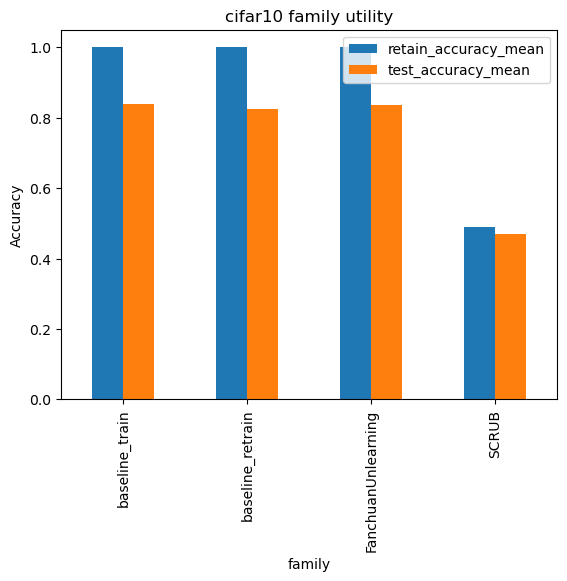

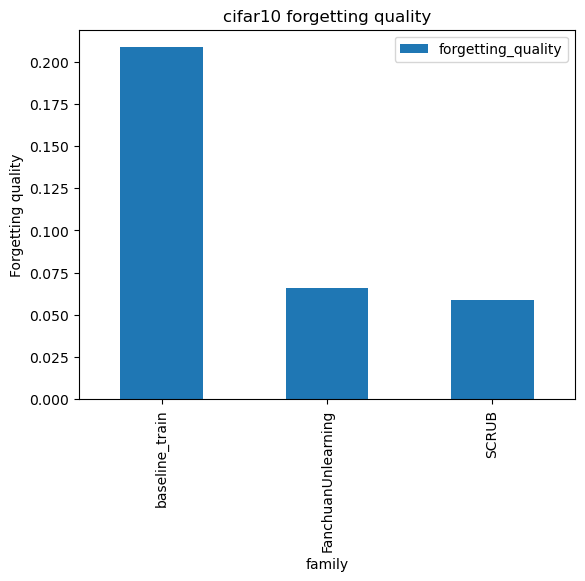

In [14]:
if hasattr(family_df, "plot"):
    ax = family_df.plot(x="family", y=["retain_accuracy_mean", "test_accuracy_mean"], kind="bar", title=f"{DATASET} family utility")
    ax.set_ylabel("Accuracy")
    plt.show()

if hasattr(comparison_df, "plot") and len(comparison_df) > 0:
    ax = comparison_df.plot(x="family", y="forgetting_quality", kind="bar", title=f"{DATASET} forgetting quality")
    ax.set_ylabel("Forgetting quality")
    plt.show()
